In [1]:
# Defining SoVI variables based on recent yearly releases. 

# SoVI 2014 
sovi_vars_2014 = [
    'MEDAGE', 'PERCAP', 'PPUNIT', 'QAGEDEP', 'QASIAN', 'QBLACK', 'QCVLUN', 'QED12LES',
    'QESL', 'QEXTRCT', 'QFEMALE', 'QFEMLBR', 'QFHH', 'QHISP', 'QHSEBRDN', 'QMOHO', 'QNATAM',
    'QNOAUTO', 'QUNINSUR', 'QPOVTY', 'QRENTER', 'QRICH200K', 'QSERV', 'QUNOCCHU', 'QSSBEN',
    'QFAM', 'MDHSEVAL', 'MDGRENT'
]

# SoVI 2019 - Removes MDHSEVAL, MDGRENT; replaces QFAM with QSNGPKIDS, adds QDISABL
sovi_vars_2019 = [
    'MEDAGE', 'PERCAP', 'PPUNIT', 'QAGEDEP', 'QASIAN', 'QBLACK', 'QCVLUN', 'QED12LES', 
    'QESL', 'QEXTRCT', 'QFEMALE', 'QFEMLBR', 'QFHH', 'QHISP', 'QHSEBRDN', 'QMOHO', 'QNATAM',
    'QNOAUTO', 'QUNINSUR', 'QPOVTY', 'QRENTER', 'QRICH200K', 'QSERV', 'QUNOCCHU', 'QSSBEN',
    'QDISABLE', 'QSNGPKIDS'
]

# 2014 and 2019 combined - QFAM and QSNGPKIDS are inverses of each other, so choose whichever
sovi_vars_com = [
    'MEDAGE', 'PERCAP', 'PPUNIT', 'QAGEDEP', 'QASIAN', 'QBLACK', 'QCVLUN', 'QED12LES', 
    'QESL', 'QEXTRCT', 'QFEMALE', 'QFEMLBR', 'QFHH', 'QHISP', 'QHSEBRDN', 'QMOHO', 'QNATAM',
    'QNOAUTO', 'QUNINSUR', 'QPOVTY', 'QRENTER', 'QRICH200K', 'QSERV', 'QUNOCCHU', 'QSSBEN',
    'QDISABLE', 'QSNGPKIDS', 'MDHSEVAL', 'MDGRENT'
]

# CHOOSE WHICH ONE:
sovi_vars = sovi_vars_com


In [2]:
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

# STANDARD SOVI PROCEDURE FOR ANY STATE'S CENSUS TRACTS #

# 1. DATA PREP AND CLEANING #

# Initialize dataframe
df_initial = pd.read_csv('../data/SoVI-vars-nationwide_2019.csv')

for col in sovi_vars:
    df_initial[col] = pd.to_numeric(df_initial[col], errors='coerce')
df_initial[sovi_vars] = df_initial[sovi_vars].mask(df_initial[sovi_vars] < 0, np.nan)

# 1.1. Choose state, if you want. Comment out to look at all tracts nationwide.
state = 'Tennessee'
df_initial = df_initial[df_initial['State Name'] == state]

# 1.2. Filter out low population tracts. Thresholds can be adjusted. 
pop_threshold, hhold_threshold = 50, 50
pop_mask = (df_initial['TOTALPOP'] > pop_threshold) & (df_initial['TOTALHHOLD'] > hhold_threshold)

num_dropped = len(df_initial) - pop_mask.sum()

df_initial = df_initial[pop_mask]

print(f"Dropped {num_dropped} tracts with low population/households.")

# 1.3. Z-score scaling
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_initial[sovi_vars]),
    columns=sovi_vars,
    index=df_initial.index
)

# 1.4. KNN Imputation
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_scaled),
    columns=sovi_vars,
    index=df_initial.index
)

num_imputed = df_initial[sovi_vars].isnull().sum().sum()
print(f"Total values imputed: {num_imputed}")


Dropped 26 tracts with low population/households.
Total values imputed: 28


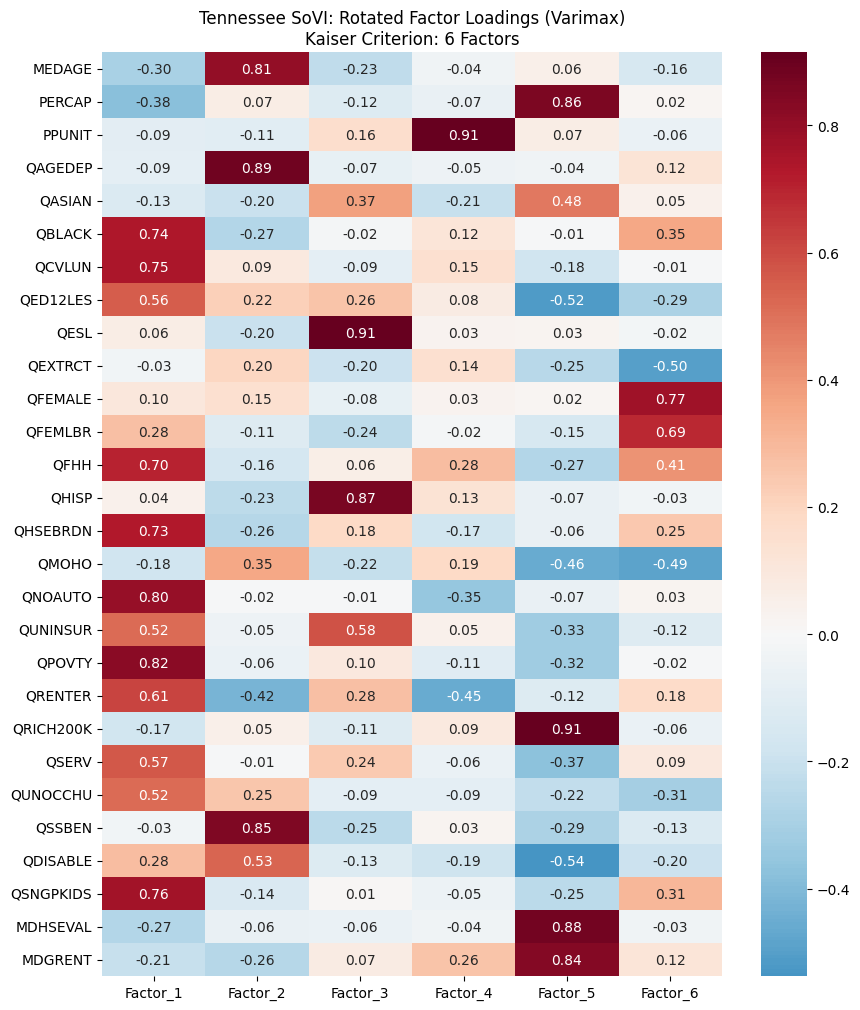

In [3]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from factor_analyzer.rotator import Rotator

# DROPPING VARIABLES #

# Removing certain variables can lead to increases in PCA performance, but be careful depending on
# the state of analysis. For example, in TN, removing QNATAM increases EV by about 4%, but other states
# have much more prominent Native American populations. Use the factor loading heatmap to decide.

# (Also make sure to run the first cell again when changing these out.)

vars_to_drop = ['QNATAM']
sovi_vars = [v for v in sovi_vars if v not in vars_to_drop]



# 2. PRINCIPAL COMPONENTS ANALYSIS (PCA) #
pca_init = PCA()
pca_init.fit(df_imputed[sovi_vars])

# 2.1. Identify number of components based on Kaiser criterion
eigenvalues = pca_init.explained_variance_
n_comp = len(eigenvalues[eigenvalues > 1])

# 2.2. Extract unrotated loadings 
# Loadings = Eigenvectors * sqrt(Eigenvalues)
pca_final = PCA(n_components=n_comp)
pca_final.fit(df_imputed[sovi_vars])
unrotated_loadings = pca_final.components_.T * np.sqrt(pca_final.explained_variance_)

# 2.3. Apply Varimax rotation
rotator = Rotator(method='varimax')
rotated_loadings = rotator.fit_transform(unrotated_loadings)

# 2.4. Extract rotated loadings
loadings_rotated = pd.DataFrame(
    rotated_loadings,
    columns=[f'Factor_{i+1}' for i in range(n_comp)],
    index=sovi_vars
)

# 2.5. Heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(loadings_rotated, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title(f'{state} SoVI: Rotated Factor Loadings (Varimax)\nKaiser Criterion: {n_comp} Factors')
plt.show()


In [4]:
# 3. CALCULATE SOVI SCORES #


# 3.1. Calculate factor score coefficients
# This is mathematically: (Correlation Matrix^-1) * Loadings
inv_corr = np.linalg.pinv(df_imputed[sovi_vars].corr())
weights = inv_corr.dot(rotated_loadings)

# 3.2. Calculate the actual factor scores for every tract
# Dot product of scaled data (tracts) and the weights (coefficients)
factor_scores = df_imputed[sovi_vars].dot(weights)
factor_scores.columns = [f'Factor_{i+1}' for i in range(n_comp)]

# 3.3. Apply any inversions (multiply factor by -1 if 'good' metrics (e.g. MDHSEVAL) are positive)
factors_to_invert = [5]  # Based on heatmap 
factor_scores_adjusted = factor_scores.copy()
for f_num in factors_to_invert:
    col_name = f'Factor_{f_num}'
    if col_name in factor_scores_adjusted.columns:
        factor_scores_adjusted[col_name] = factor_scores_adjusted[col_name] * -1

# 3.4. Final SoVI calculation
df_initial['SoVI_Score'] = factor_scores_adjusted.sum(axis=1)

# Add adjusted scores to the main dataframe
adj_columns = {f'Factor_{i+1}': f'Factor_{i+1}' for i in range(n_comp)}
df_final = pd.concat([df_initial, factor_scores_adjusted.rename(columns=adj_columns)], axis=1)

print("\nFinal SoVI calculation complete!\n")

# Calculate individual and cumulative variance ratios
var_exp = pca_init.explained_variance_ratio_
cum_var_exp = np.cumsum(var_exp)

print(f"{'Factor':<10} | {'Expl. Var (%)':<15} | {'Cumul. Var (%)'}")
print("-" * 45)

for i in range(n_comp):
    print(f"Factor {i+1:<3} | {var_exp[i]*100:<15.2f}% | {cum_var_exp[i]*100:.2f}%")

print("")
print(df_final.head())

df_final.to_csv('/Users/maxbdixon/Desktop/SoVI-TN_2019.csv')


Final SoVI calculation complete!

Factor     | Expl. Var (%)   | Cumul. Var (%)
---------------------------------------------
Factor 1   | 30.79          % | 30.79%
Factor 2   | 19.36          % | 50.15%
Factor 3   | 9.71           % | 59.86%
Factor 4   | 5.62           % | 65.48%
Factor 5   | 4.71           % | 70.19%
Factor 6   | 4.31           % | 74.50%

             GEOID State Name County Name  Year  TOTALPOP  TOTALHHOLD  \
60132  47001020100  Tennessee   Anderson   2019      3196        1510   
60133  47001020201  Tennessee   Anderson   2019      4080        1712   
60134  47001020202  Tennessee   Anderson   2019      3973        1731   
60135  47001020300  Tennessee   Anderson   2019      3851        1486   
60136  47001020400  Tennessee   Anderson   2019      4275        1877   

       QAGEDEP  QFEMALE  MEDAGE  QBLACK  ...  QUNOCCHU  MDGRENT  MDHSEVAL  \
60132   0.2369   0.5332    34.6  0.1974  ...    0.1639    796.0  163200.0   
60133   0.2341   0.5194    44.9  0.0358  ... 

In [14]:
import geopandas as gpd

# 1. Load the tracts map and set index - CURRENTLY ONLY TN TRACTS
gdf = gpd.read_file('../data/tracts2010.gpkg')
gdf['GEOID'] = gdf['GEOID'].astype(str)
gdf = gdf.set_index("GEOID")

# 2. Get the GEOIDs from the original dataframe
geoids = df_initial['GEOID'].astype(str)

# 3. Prepare the results
results_indexed = df_final.copy()
if 'GEOID' in results_indexed.columns:
    results_indexed = results_indexed.drop(columns=['GEOID'])

results_indexed.index = geoids

# 4. Join geometry with results
gdf_final = gdf[['geometry']].join(results_indexed, how='inner')

# 5. Export
if not gdf_final.empty:
    output_file = '../results/SoVI_2019.gpkg'
    # reset_index(names='GEOID') ensures the column is named correctly in the GPKG
    gdf_final.to_file(output_file, driver="GPKG")
    print(f"Exported to: {output_file}")
else:
    print("Join failed. Check index alignment.")

Exported to: ../results/SoVI_2019.gpkg


In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Setup
comp_range = range(2, 7) 
k_range = range(2, 9)    
results = []

print(f"{'Comp':<5} | {'K':<3} | {'Silh (↑)':<8} | {'D-B (↓)':<8} | {'Var Exp % (↑)':<10}")
print("-" * 45)

for n_comp in comp_range:
    # 1. Slice
    X_raw = factor_scores.iloc[:, :n_comp].copy()
    
    # 2. Replicate your "Experimental" logic (Adding SoVI_Score)
    X_raw['SoVI_Score'] = X_raw.sum(axis=1) # Or however you calculated it
    
    # 3. Replicate your Scaling
    scaler = StandardScaler()
    X_for_metrics = scaler.fit_transform(X_raw)
    
    # 4. Calculate Total SS on the SCALED data
    total_ss = np.sum((X_for_metrics - np.mean(X_for_metrics, axis=0))**2)
    
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        labels = km.fit_predict(X_for_metrics)
        
        # Calculate metrics on the same scaled data
        sil = silhouette_score(X_for_metrics, labels)
        db = davies_bouldin_score(X_for_metrics, labels)
        var_exp = (1 - (km.inertia_ / total_ss)) * 100

        results.append({
            'Components': n_comp,
            'K': k,
            'Silhouette': sil,
            'Davies_Bouldin': db,
            'KMeans_Var_Exp': var_exp
        })
        
        print(f"{n_comp:<5} | {k:<3} | {sil:<8.3f} | {db:<8.3f} | {var_exp:<10.1f}%")

# 2. Convert to dataframe to view
summary_df = pd.DataFrame(results)

Comp  | K   | Silh (↑) | D-B (↓)  | Var Exp % (↑)
---------------------------------------------
2     | 2   | 0.412    | 1.038    | 39.7      %
2     | 3   | 0.400    | 0.847    | 60.3      %
2     | 4   | 0.364    | 0.885    | 69.5      %
2     | 5   | 0.391    | 0.772    | 75.6      %
2     | 6   | 0.364    | 0.826    | 79.9      %
2     | 7   | 0.349    | 0.861    | 82.0      %
2     | 8   | 0.327    | 0.898    | 83.9      %
3     | 2   | 0.376    | 1.318    | 30.3      %
3     | 3   | 0.301    | 1.208    | 45.4      %
3     | 4   | 0.340    | 0.941    | 59.6      %
3     | 5   | 0.283    | 1.029    | 65.7      %
3     | 6   | 0.294    | 0.988    | 69.7      %
3     | 7   | 0.306    | 0.964    | 73.4      %
3     | 8   | 0.285    | 0.987    | 76.2      %
4     | 2   | 0.328    | 1.580    | 22.5      %
4     | 3   | 0.287    | 1.402    | 36.1      %
4     | 4   | 0.287    | 1.218    | 47.1      %
4     | 5   | 0.240    | 1.172    | 55.5      %
4     | 6   | 0.210    | 1.243    | 59.3

In [30]:
import pandas as pd
import geopandas as gpd
from sklearn.cluster import KMeans

# --- CONFIGURATION ---
base_gpkg = '/Users/maxbdixon/Documents/GitHub/SoVI-clustering/data/tracts2010.gpkg'
output_path = '../results/K-SoVI_2019.gpkg'
best_n = 2  # PCA components used for clustering
best_k = 5  # Number of clusters

# 1. PREP GEOMETRY
gdf_base = gpd.read_file(base_gpkg)
gdf_base['GEOID'] = gdf_base['GEOID'].astype(str)
gdf_base = gdf_base.set_index('GEOID')

# 2. ALIGN DATA AND RE-ORDER CLUSTERS
# Use df_initial to get the correct GEOID order for factor_scores/df_imputed
export_geoids = df_initial['GEOID'].astype(str)

# Run K-Means on the selected factors
X_clustering = factor_scores.iloc[:, :best_n]
km = KMeans(n_clusters=best_k, init='k-means++', n_init=50, random_state=42)
raw_labels = km.fit_predict(X_clustering)

# Re-order logic: Rank clusters by mean poverty (1 = Lowest, 5 = Highest)
cluster_poverty = pd.DataFrame({
    'raw_label': raw_labels, 
    'poverty': df_imputed['QPOVTY']
}).groupby('raw_label')['poverty'].mean().sort_values().index

mapping = {old_label: i+1 for i, old_label in enumerate(cluster_poverty)}
final_cluster_ids = [mapping[label] for label in raw_labels]

# 3. ASSEMBLE EXPORT DATAFRAME
export_df = df_initial.copy()

for col in factor_scores.columns:
    export_df[col] = factor_scores[col].values

# Add the poverty-ordered clusters
export_df['SoVI_Cluster'] = final_cluster_ids

# Final index alignment
export_df.index = export_geoids
if 'GEOID' in export_df.columns:
    export_df = export_df.drop(columns=['GEOID'])

# 4. JOIN AND SAVE
gdf_final = gdf_base[['geometry']].join(export_df, how='inner')

if not gdf_final.empty:
    gdf_final.to_file(output_path, driver="GPKG")
    print("--- EXPORT COMPLETE ---")
    print(f"File: {output_path}")
else:
    print("Export failed")


# CLUSTER PROFILES #

# 1. Identify columns
factor_cols = [c for c in gdf_final.columns if 'Factor' in c]
score_cols = ['SoVI_Score'] if 'SoVI_Score' in gdf_final.columns else []

available_raw = [v for v in sovi_vars if v in gdf_final.columns]
all_profile_cols = factor_cols + score_cols + available_raw

# 2. Calculate cluster means
cluster_means = gdf_final.groupby('SoVI_Cluster')[all_profile_cols].mean()

# 3. Display results
display(cluster_means.round(3).T)


--- EXPORT COMPLETE ---
File: ../results/K-SoVI_2019.gpkg


SoVI_Cluster,1,2,3,4,5
Factor_1,-0.572,-0.445,0.254,0.930,2.761
Factor_2,-0.897,0.323,1.269,-1.297,0.107
Factor_3,0.088,-0.052,0.028,0.100,-0.224
Factor_4,0.064,0.060,-0.119,-0.189,0.107
Factor_5,0.254,-0.146,0.105,-0.165,0.104
Factor_6,0.117,-0.049,-0.187,-0.053,0.432
SoVI_Score,-1.454,-0.018,1.139,-0.344,3.079
MEDAGE,35.876,42.501,46.220,31.281,35.484
PERCAP,33297.878,30044.472,30214.565,21533.447,16147.556
PPUNIT,2.585,2.538,2.424,2.455,2.471
